In [271]:
import cv2
import pathlib
import os
import math

Display raw video feed

In [272]:
try:
    video_path = pathlib.Path(os.getcwd()) / "morse_code_test_videos\\Lamp.mp4"
    
    print("Path:", video_path)
    
    print("Video Path Valid:", video_path.exists())
    
    video = cv2.VideoCapture(video_path)
    
    while True:
        ret, frame = video.read()
        if not ret or not frame is not None:
            break
        
        if cv2.waitKey(int(1000 / video.get(cv2.CAP_PROP_FPS))) & 0xFF == ord("q"):
            break
        
        cv2.imshow("Video", frame)
finally:
    cv2.destroyAllWindows()

Path: C:\Users\AlexD\Documents\Git\team-bath-rov-ui\source\morse_code_test_videos\Lamp.mp4
Video Path Valid: True


Allow users to choose an initial window position

Blob Parameters

In [273]:
window_size = 20
blob_area_threshold = 20
min_intensity_threshold = 200
maximum_blob_travel_distance = 25


In [274]:
window_position = None
# Mouse callback function
def click_event(event, x, y, flags, param):
    global window_position
    if event == cv2.EVENT_LBUTTONDOWN:
        window_position = (x, y)

In [275]:
video = cv2.VideoCapture(video_path)

# Set mouse callback function for the window
cv2.namedWindow("Video")
cv2.setMouseCallback("Video", click_event)

while window_position is None:
    ret, frame = video.read()
    if not ret or not frame is not None:
        break
    
    if cv2.waitKey(int(1000 / video.get(cv2.CAP_PROP_FPS))) & 0xFF == ord("q"):
        break
        
    cv2.imshow("Video", frame)
    
cv2.destroyAllWindows()

In [276]:
print(f"Selected initial window position at {window_position}")

Selected initial window position at (743, 381)


Collect average pixel intensities in selected window

In [277]:
video = cv2.VideoCapture(video_path)

# Set mouse callback function for the window
cv2.namedWindow("Video")
cv2.setMouseCallback("Video", click_event)

cv2.namedWindow("Gray Video")
cv2.setMouseCallback("Gray Video", click_event)

means = []

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

speed = 1

while True:
    ret, frame = video.read()
    
    if not ret or not frame is not None:
        break
    
    if cv2.waitKey(int(1000 / video.get(cv2.CAP_PROP_FPS) / speed)) & 0xFF == ord("q"):
        break
    
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    cv2.imshow("Pre Threshold Frame", gray_frame)
    
    _, gray_frame = cv2.threshold(gray_frame, min_intensity_threshold, 255, cv2.THRESH_BINARY)
    
    contours, _ = cv2.findContours(gray_frame, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    best_blob = None
    best_circularity = 0
    best_area = 0
    best_score = 0
    
    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        
        if area < blob_area_threshold:
            continue
        
        if perimeter > 0:
            circularity = (4 * math.pi * area) / (perimeter ** 2)
        else:
            circularity = 0
            
        score = (area * 0.5) + (circularity * 5000)
        
        if score > best_score:
            best_score = score
            best_blob = contour
            best_area = area
            best_circularity = best_circularity
            
    if best_blob is not None:
        (x, y), radius = cv2.minEnclosingCircle(best_blob)
        center = (int(x), int(y))
        
        dist = math.sqrt((center[0] - window_position[0]) ** 2 + (center[1] - window_position[1]) ** 2 )
        if dist < maximum_blob_travel_distance:
            window_position = center
            radius = int (radius)
            cv2.circle(frame, center, radius, (255, 0, 0), 2)
        
    window_offset = window_size // 2
    
    window = gray_frame[window_position[1]-window_offset:window_position[1]+window_offset,
                        window_position[0]-window_offset:window_position[0]+window_offset]
    
    means.append(window.mean())
    
    cv2.imshow("Video", frame)
    cv2.imshow("Gray Video", gray_frame)
    cv2.imshow("Window", window)
    
cv2.destroyAllWindows()

Plot the means over time

In [278]:
import matplotlib.pyplot as plt

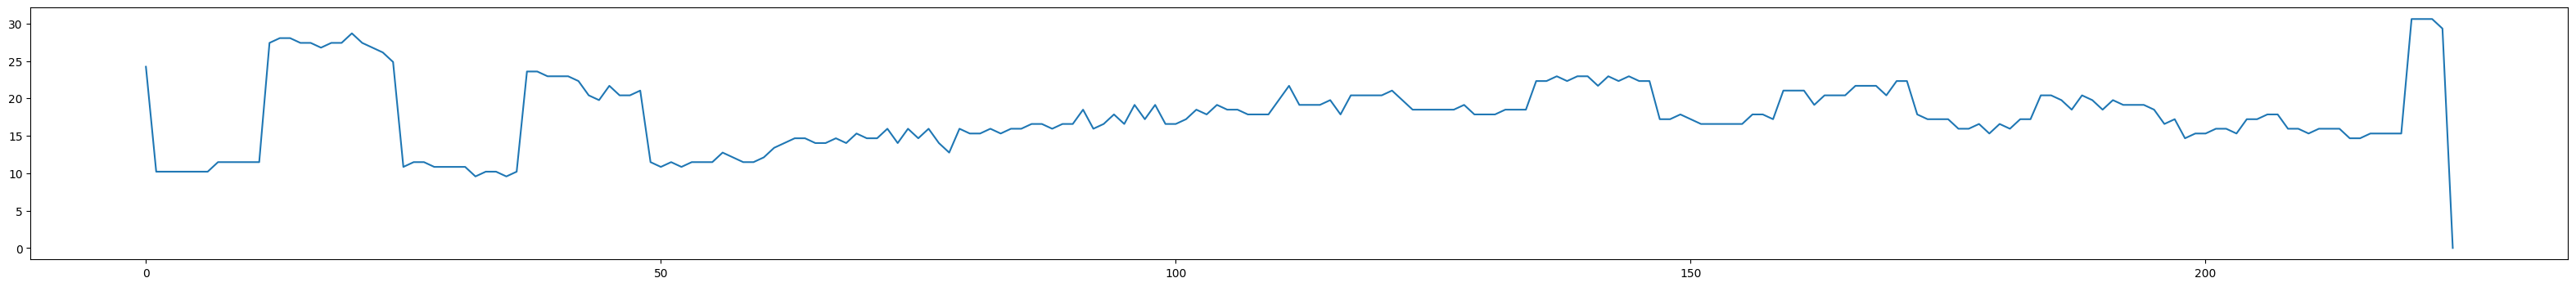

In [279]:
plt.figure(figsize=(40, 4))

plt.plot(range(len(means)), means)

plt.show()

Cleanup and categorisation of peaks

In [280]:
threshold = 160
max_length = 4

signal = []

signal_state_lengths = []

state_high = True

current_state_length = 0

for mean in means:
    signal.append(1 if mean >= threshold else 0)
    
    if mean >= threshold:
        if state_high:
            # The state is currently high and has remained high
            current_state_length += 1
        else:
            # The state was previously low and is now high
            # Mark the length of the low state
            signal_state_lengths.append((False, current_state_length))
            state_high = True
            current_state_length = 1
    else:
        if state_high:
            # The state is currently low and was previously high
            # Mark the length of the high state
            signal_state_lengths.append((True, current_state_length))
            state_high = False
            current_state_length = 1
        else:
            # The state was previously low and is still low
            current_state_length += 1
            
    

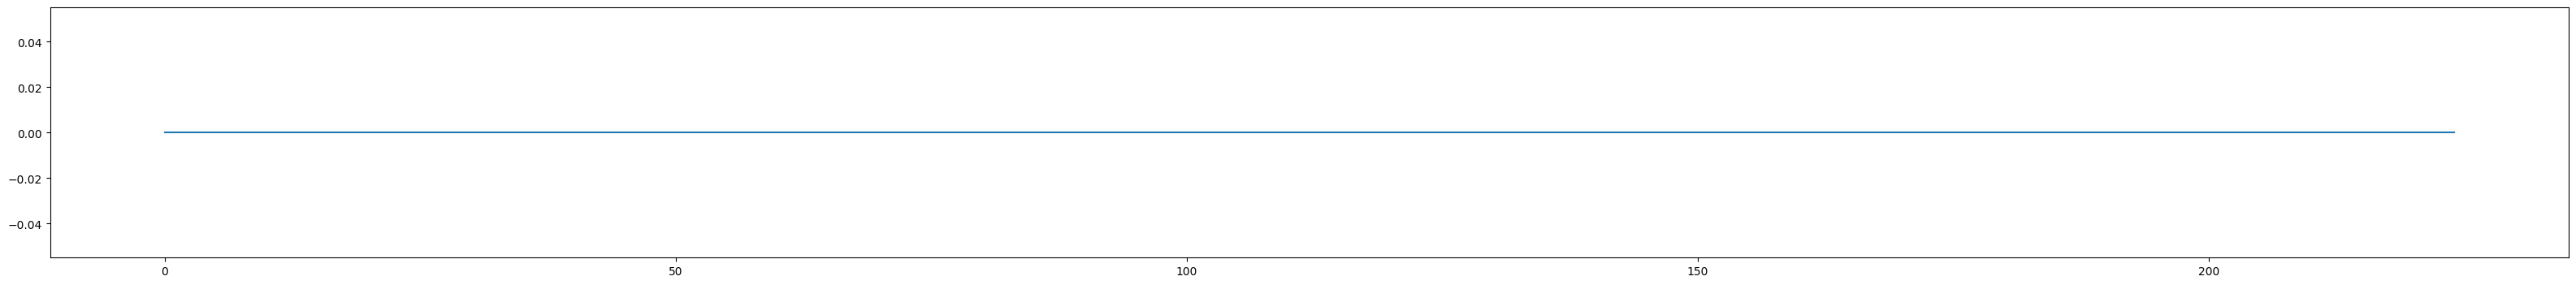

In [281]:
plt.figure(figsize=(40, 4))

plt.plot(range(len(signal)), signal)

plt.show()

In [282]:
low = []
high = []

for state, length in signal_state_lengths:
    print("High" if state else "Low", length)
    if state:
        high.append(length)
    else:
        low.append(length)
    

High 0


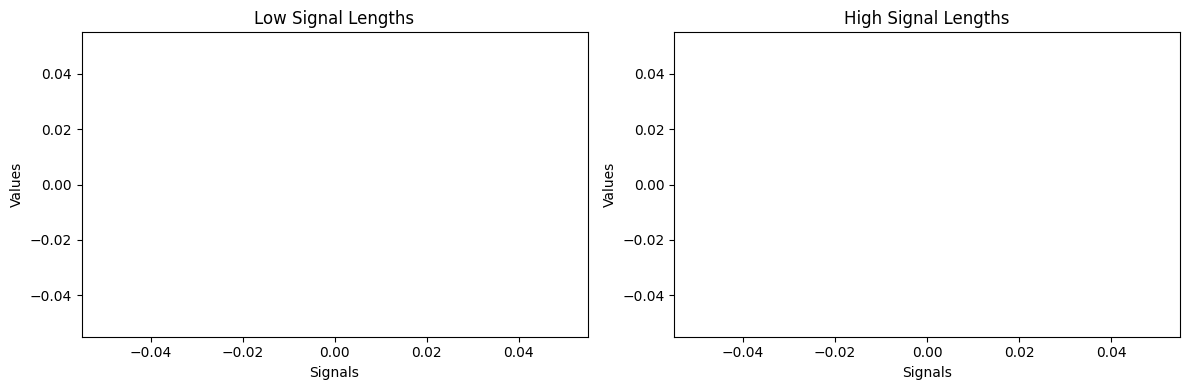

In [283]:
# Create figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# First subplot
ax1.bar(range(len(low)), low, color='skyblue')
ax1.set_title('Low Signal Lengths')
ax1.set_ylabel('Values')
ax1.set_xlabel('Signals')

# Second subplot
ax2.bar(range(len(low)), low, color='salmon')
ax2.set_title('High Signal Lengths')
ax2.set_ylabel('Values')
ax2.set_xlabel('Signals')

plt.tight_layout()
plt.show()

By interpreting the graphs we can find thresholds to seperate long and short signal lengths

In [284]:
low_short_threshold = 36  # Anything below this threshold is seen as an intermitent pause when transmitting a single character
                          # Anything above this threshold is a pause between characters
high_short_threshold = 36 # Anything above this threshold is a long signal (-)
                          # Anything below this threshold is a short signal (*) 

With our thresholds, we can now interpret the varying signal lengths and transform them into morse code characters

In [285]:
reconstruction = []

current_morse = ""

for state, length in signal_state_lengths:
    if state:
        if length >= high_short_threshold:
            current_morse += "-"
        else:
            current_morse += "."
    else:
        if length <= low_short_threshold:
            pass # Short pauses can be ignored - These simply separate long and short signals
        elif current_morse != "":
            reconstruction.append(current_morse)
            current_morse = ""
    if len(current_morse) >= max_length:
        reconstruction.append(current_morse)
        current_morse = ""
        
        

In [286]:
morse_dict = {
        '.-': 'A', '-...': 'B', '-.-.': 'C', '-..': 'D',
        '.': 'E', '..-.': 'F', '--.': 'G', '....': 'H',
        '..': 'I', '.---': 'J', '-.-': 'K', '.-..': 'L',
        '--': 'M', '-.': 'N', '---': 'O', '.--.': 'P',
        '--.-': 'Q', '.-.': 'R', '...': 'S', '-': 'T',
        '..-': 'U', '...-': 'V', '.--': 'W', '-..-': 'X',
        '-.--': 'Y', '--..': 'Z'
    }

inverse_morse = {}

for key in morse_dict:
    inverse_morse[morse_dict[key]] = key

def morse_to_char(morse_str):   
    return morse_dict.get(morse_str, None)


In [287]:
import string

correct = 0
for i, morse in enumerate(reconstruction[1:]):
    if i > 25:
        break
    char_ = morse_to_char(morse)
    correct += char_ == string.ascii_uppercase[i]
    print(morse,"=",char_, "Correct:", char_ == string.ascii_uppercase[i], "Should be", inverse_morse[string.ascii_uppercase[i]])

In [288]:
print(f"{(correct / 26) * 100:.2f} % accuracy")

0.00 % accuracy
